<a href="https://colab.research.google.com/github/sathu0622/DL_Assigment/blob/feature%2Fsathushan/Transfer_Learning_(MobileNetV2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Introduction**

This project applies Transfer Learning to classify images from the Fashion MNIST dataset — a collection of 70,000 grayscale images of 10 clothing categories.

Transfer Learning leverages a pre-trained model (MobileNetV2) that has already learned rich feature representations from a large dataset (ImageNet). By fine-tuning this model on Fashion MNIST:

We save training time and computational resources.

The model can achieve high accuracy quickly because it uses features already learned in the pre-training phase.

In this implementation:

Images are resized and converted to RGB to match MobileNetV2 input requirements.

Data augmentation is applied to improve generalization.

The last layers of MobileNetV2 are fine-tuned for Fashion MNIST classification.

A learning rate scheduler and early stopping are used to improve training stability and performance.

### **Import Required Libraries**

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from PIL import Image

# **Load Fashion-MNIST Dataset**

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

IMG_SIZE = 96
BATCH_SIZE = 64

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


# **Preprocess Function**

In [3]:
def preprocess(image, label):
    image = tf.expand_dims(image, -1)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.image.grayscale_to_rgb(image)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# **Data Pipeline**

In [4]:
train_ds = (tf.data.Dataset.from_tensor_slices((x_train, y_train))
            .shuffle(10000)
            .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

test_ds = (tf.data.Dataset.from_tensor_slices((x_test, y_test))
           .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
           .batch(BATCH_SIZE)
           .prefetch(tf.data.AUTOTUNE))

# **Data Augmentation**

In [5]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.2),
])

# **Load and Fine-Tune MobileNetV2**

In [6]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze early layers, fine-tune later layers
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


# **Learning Rate Scheduler & Build the Model**

In [7]:
initial_lr = 1e-4
lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=initial_lr,
    first_decay_steps=1000
)

model3 = models.Sequential([
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])


# **Compile the Model**

In [8]:
model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# **Train the Model**

In [9]:
history3 = model3.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True)]
)


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 84s 67ms/step - accuracy: 0.6928 - loss: 0.9479 - val_accuracy: 0.8518 - val_loss: 0.4288
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 61s 65ms/step - accuracy: 0.8328 - loss: 0.4786 - val_accuracy: 0.8725 - val_loss: 0.3704
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 58s 62ms/step - accuracy: 0.8670 - loss: 0.3768 - val_accuracy: 0.8942 - val_loss: 0.2947
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 58s 62ms/step - accuracy: 0.8732 - loss: 0.3561 - val_accuracy: 0.8897 - val_loss: 0.3173
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 57s 61ms/step - accuracy: 0.8816 - loss: 0.3308 - val_accuracy: 0.8992 - val_loss: 0.2952
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 56s 60ms/step - accuracy: 0.8936 - loss: 0.2916 - val_accuracy: 0.9076 - val_loss: 0.2540
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 57s 61ms/step - accuracy: 0.9046 - loss: 0.2639 - val_accuracy: 0.9085 - val_loss: 0.2468
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 58s 62ms/step - accuracy: 0.9057 - loss: 0.2602 - 

# **Evaluate Model Performance**

In [10]:
test_loss, test_acc = model3.evaluate(test_ds)
print(f"\n✅ Final Test Accuracy (Transfer Learning - Tuned): {test_acc:.4f}")
print(f"✅ Final Test Loss: {test_loss:.4f}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9093 - loss: 0.2469

✅ Final Test Accuracy (Transfer Learning - Tuned): 0.9085
✅ Final Test Loss: 0.2468


# **Visualize Training Progress**

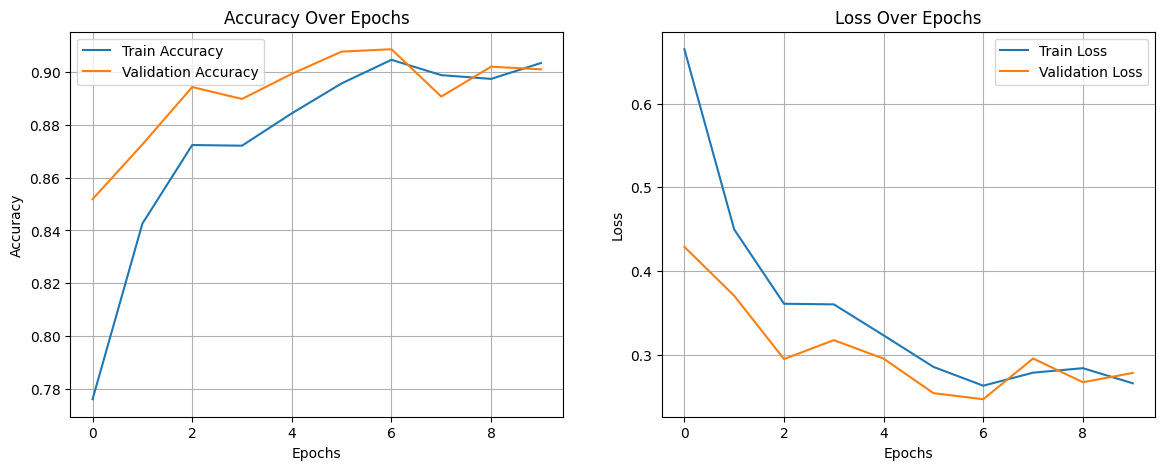

In [11]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(history3.history['accuracy'], label='Train Accuracy')
plt.plot(history3.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history3.history['loss'], label='Train Loss')
plt.plot(history3.history['val_loss'], label='Validation Loss')
plt.title("Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# **Distribution of Pixel Intensities**

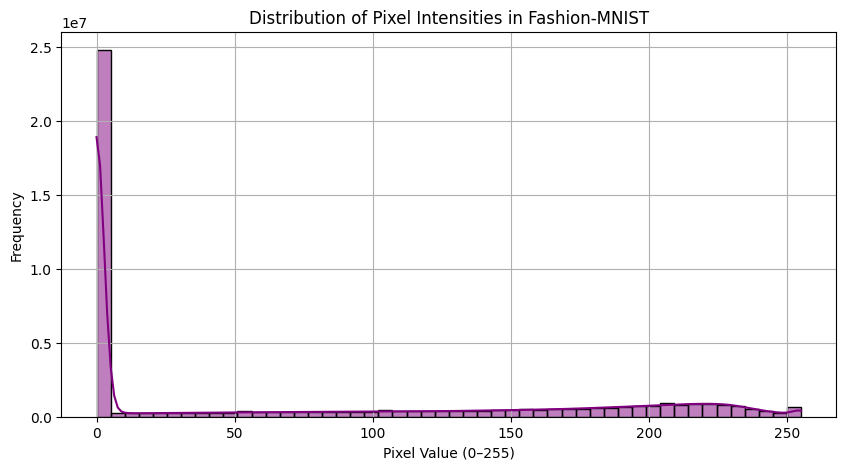

In [12]:
pixel_values = x_train.flatten()
plt.figure(figsize=(10,5))
sns.histplot(pixel_values, bins=50, kde=True, color='purple')
plt.title("Distribution of Pixel Intensities in Fashion-MNIST")
plt.xlabel("Pixel Value (0–255)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# **Predict Random Test Samples**

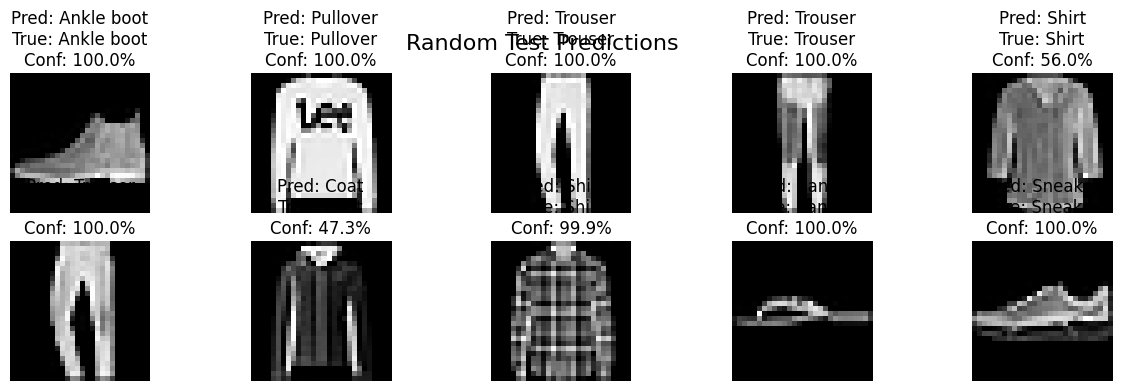

In [13]:
sample_images = x_test[:10]
sample_labels = y_test[:10]

plt.figure(figsize=(15,4))
for i in range(10):
    img = tf.image.resize(tf.expand_dims(sample_images[i], -1), [IMG_SIZE, IMG_SIZE])
    img = tf.image.grayscale_to_rgb(img)
    img = tf.expand_dims(img, 0) / 255.0
    pred = model3.predict(img, verbose=0)
    pred_label = np.argmax(pred)
    confidence = np.max(pred) * 100

    plt.subplot(2,5,i+1)
    plt.imshow(sample_images[i], cmap='gray')
    plt.title(f"Pred: {class_names[pred_label]}\nTrue: {class_names[sample_labels[i]]}\nConf: {confidence:.1f}%")
    plt.axis('off')
plt.suptitle("Random Test Predictions", fontsize=16)
plt.show()

# **Custom Prediction**


📂 Upload a custom image (jpg/png of clothing item)...


Saving black-classic-shirt.jpg to black-classic-shirt.jpg


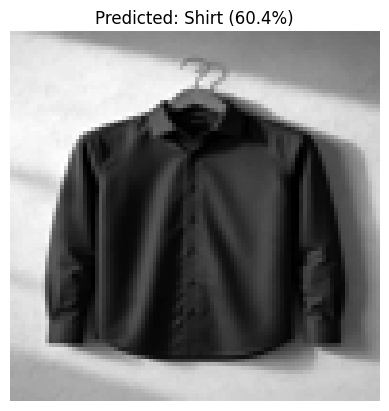

In [16]:
from google.colab import files

print("\n📂 Upload a custom image (jpg/png of clothing item)...")
uploaded = files.upload()

for fname in uploaded.keys():
    path = fname
    img = Image.open(path).convert("L").resize((IMG_SIZE, IMG_SIZE))
    img_rgb = np.stack([img]*3, axis=-1)
    img_array = np.expand_dims(img_rgb, 0) / 255.0

    pred = model3.predict(img_array, verbose=0)
    pred_label = np.argmax(pred)
    confidence = np.max(pred) * 100

    plt.imshow(img, cmap='gray')
    plt.title(f"Predicted: {class_names[pred_label]} ({confidence:.1f}%)")
    plt.axis('off')
    plt.show()

# **Dataset Analysis and Visualization **

Training data shape: (60000, 28, 28) (60000,)
Test data shape: (10000, 28, 28) (10000,)


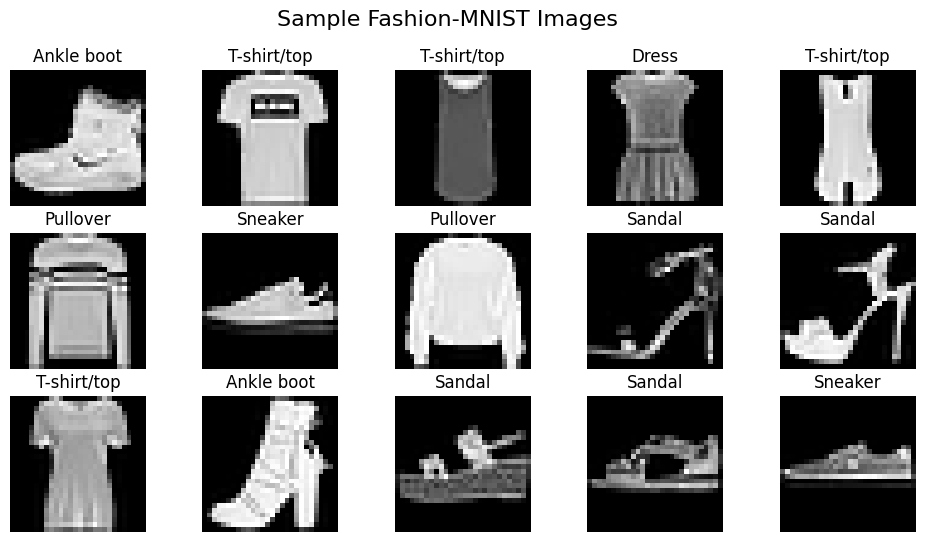

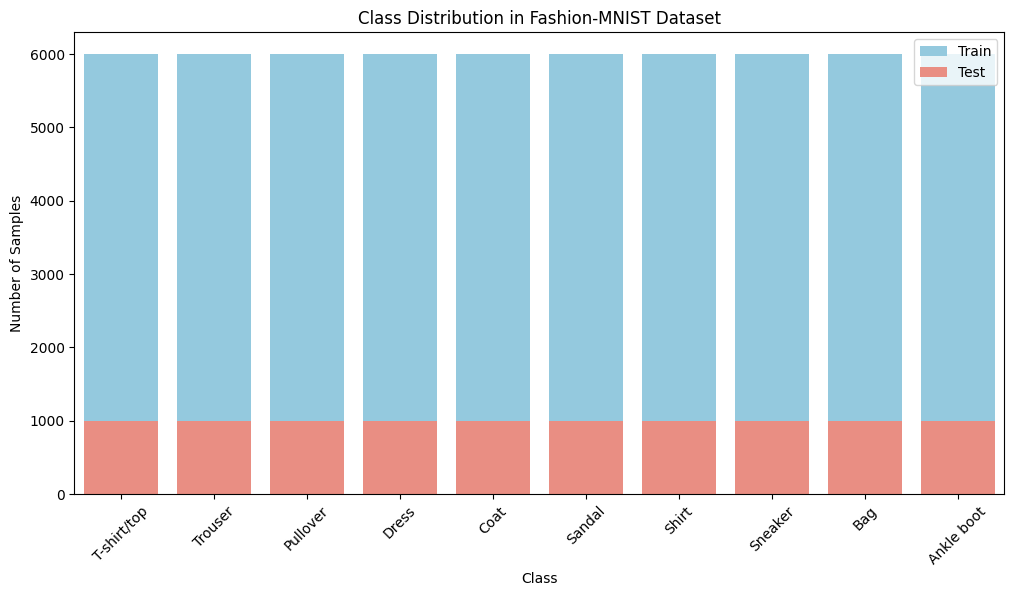

         Class  Train Count  Test Count
0  T-shirt/top         6000        1000
1      Trouser         6000        1000
2     Pullover         6000        1000
3        Dress         6000        1000
4         Coat         6000        1000
5       Sandal         6000        1000
6        Shirt         6000        1000
7      Sneaker         6000        1000
8          Bag         6000        1000
9   Ankle boot         6000        1000
Min pixel value: 0
Max pixel value: 255
Mean pixel value: 72.94035223214286
Standard deviation: 90.02118235130519


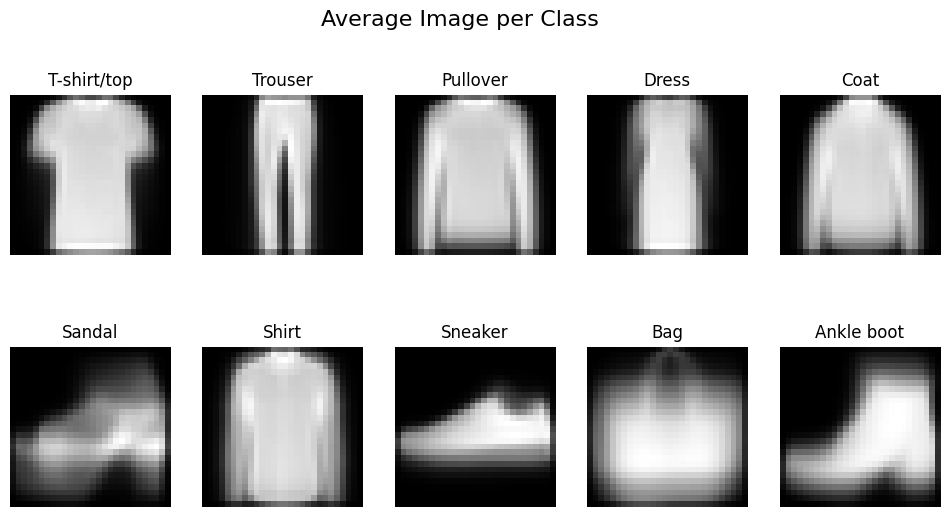

In [15]:
# ===== Fashion-MNIST Dataset Analysis =====
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# -----------------------------
# 1. Load Dataset
# -----------------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Class labels
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# -----------------------------
# 2. Dataset Shapes
# -----------------------------
print("Training data shape:", x_train.shape, y_train.shape)
print("Test data shape:", x_test.shape, y_test.shape)

# -----------------------------
# 3. Visualize Sample Images
# -----------------------------
plt.figure(figsize=(12, 6))
for i in range(15):
    plt.subplot(3, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.suptitle("Sample Fashion-MNIST Images", fontsize=16)
plt.show()

# -----------------------------
# 4. Class Distribution (Train & Test)
# -----------------------------
train_counts = np.bincount(y_train)
test_counts = np.bincount(y_test)

df_counts = pd.DataFrame({
    'Class': class_names,
    'Train Count': train_counts,
    'Test Count': test_counts
})

plt.figure(figsize=(12,6))
sns.barplot(x='Class', y='Train Count', data=df_counts, color='skyblue', label='Train')
sns.barplot(x='Class', y='Test Count', data=df_counts, color='salmon', label='Test')
plt.xticks(rotation=45)
plt.title("Class Distribution in Fashion-MNIST Dataset")
plt.ylabel("Number of Samples")
plt.legend()
plt.show()

print(df_counts)

# -----------------------------
# 5. Check Image Statistics
# -----------------------------
print("Min pixel value:", np.min(x_train))
print("Max pixel value:", np.max(x_train))
print("Mean pixel value:", np.mean(x_train))
print("Standard deviation:", np.std(x_train))

# -----------------------------
# 6. Plot Average Image per Class
# -----------------------------
plt.figure(figsize=(12,6))
for i, label in enumerate(class_names):
    class_images = x_train[y_train == i]
    avg_image = np.mean(class_images, axis=0)
    plt.subplot(2, 5, i+1)
    plt.imshow(avg_image, cmap='gray')
    plt.title(label)
    plt.axis('off')
plt.suptitle("Average Image per Class", fontsize=16)
plt.show()
